## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## **2. Load Dataset**





In [2]:
link = "https://raw.githubusercontent.com/RaiyanEOF/CSE-427-Lab/refs/heads/main/ai_student_impact_dataset%20(1).csv"
df = pd.read_csv(link)
print("Dataset was loaded successfully!")

Dataset was loaded successfully!


## **3. View Dataset**

In [3]:
print("First 10 rows of the dataset : ")
df.head(10)

First 10 rows of the dataset : 


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


## **4. Dataset Basic Information**

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(50000, 16)

Column Names:
['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']

Data Types:
Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level  

## **5. Y Data Profiling**

In [5]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.0 MB/s eta 0:00:00


In [6]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title = "Impact of AI on students", explorative= True)

profile.to_file("ydata.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:04<00:00,  3.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## **6. Target Distribution**

Burnout Risk Distribution:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

Percentage:
Burnout_Risk_Level
Medium    42.29
Low       32.74
High      24.97
Name: proportion, dtype: float64


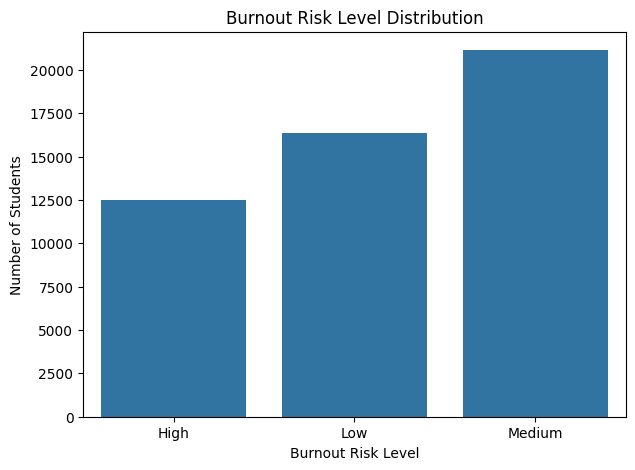

In [7]:
target = "Burnout_Risk_Level"

print("Burnout Risk Distribution:")
print(df[target].value_counts())

print("\nPercentage:")
print(
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target
)

plt.title("Burnout Risk Level Distribution")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Number of Students")

plt.show()

## **7. Data Cleaning**

In [8]:
df = df.drop_duplicates()


if "Student_ID" in df.columns:
    df = df.drop(columns=["Student_ID"])


df = df.dropna(
    subset=[target]
)

print("Final dataset shape:")
print(df.shape)

Final dataset shape:
(50000, 15)


## **8. Seperate feature and target**

In [9]:
X = df.drop(columns=[target])

y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

Features shape: (50000, 14)
Target shape: (50000,)

Target classes:
['High' 'Low' 'Medium']


## **9. Train Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (40000, 14)
Testing data : (10000, 14)


## **10. Numerical and Categorical features**

In [11]:
numeric_columns = X.select_dtypes(
    include=np.number
).columns

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']

Categorical columns:
['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy']


## **11. Preprocessing**

In [12]:
numeric_preprocessing = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "scaler",
        StandardScaler()
    )
])


categorical_preprocessing = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])



preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_preprocessing,
        numeric_columns
    ),

    (
        "categorical",
        categorical_preprocessing,
        categorical_columns
    )

])


print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## **12. SMOTE Oversampling**

In [13]:


# !pip install imbalanced-learn

## **13. Training Data Class Distribution Before Oversampling**

Class distribution before SMOTE oversampling:
Burnout_Risk_Level
Medium    16915
Low       13095
High       9990
Name: count, dtype: int64


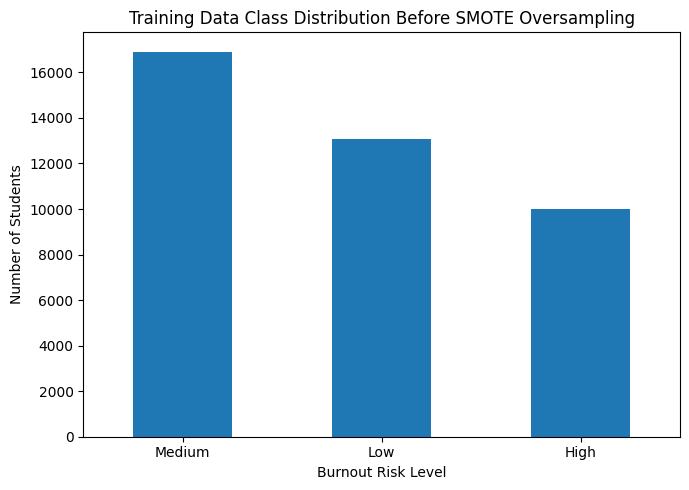

In [14]:
train_class_counts = y_train.value_counts()

print("Class distribution before SMOTE oversampling:")
print(train_class_counts)

plt.figure(figsize=(7, 5))
train_class_counts.plot(kind="bar")
plt.title("Training Data Class Distribution Before SMOTE Oversampling")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **14. Preprocessing Training and Testing Data**

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessed training shape:", X_train_processed.shape)
print("Preprocessed testing shape :", X_test_processed.shape)

Preprocessed training shape: (40000, 31)
Preprocessed testing shape : (10000, 31)


## **15. SMOTE Oversampling Implementation**

In [16]:
smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("SMOTE oversampling completed successfully.")
print("Original training shape:", X_train_processed.shape)
print("Oversampled training shape:", X_train_smote.shape)

SMOTE oversampling completed successfully.
Original training shape: (40000, 31)
Oversampled training shape: (50745, 31)


## **16. Training Data Class Distribution After Oversampling**

Class distribution after SMOTE oversampling:
Burnout_Risk_Level
High      16915
Medium    16915
Low       16915
Name: count, dtype: int64


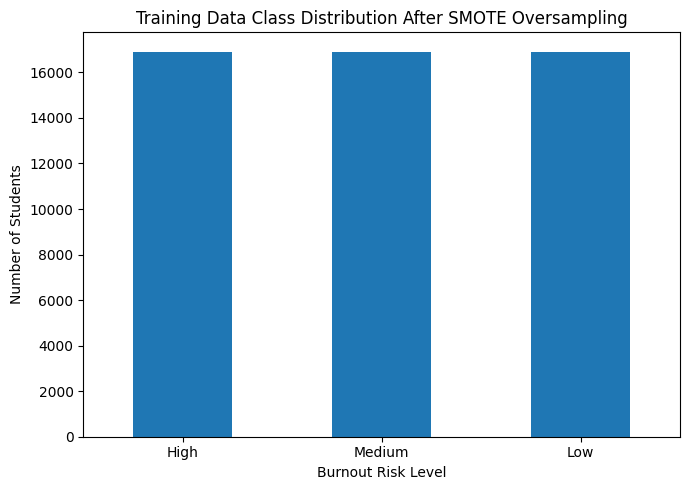

In [17]:
print("Class distribution after SMOTE oversampling:")
print(pd.Series(y_train_smote).value_counts())

plt.figure(figsize=(7, 5))
pd.Series(y_train_smote).value_counts().plot(kind="bar")
plt.title("Training Data Class Distribution After SMOTE Oversampling")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **17. Baseline Model**

In [18]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(
    X_train_smote,
    y_train_smote
)

baseline_prediction = baseline.predict(
    X_test_processed
)

print(
    classification_report(
        y_test,
        baseline_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.25      1.00      0.40      2497
         Low       0.00      0.00      0.00      3274
      Medium       0.00      0.00      0.00      4229

    accuracy                           0.25     10000
   macro avg       0.08      0.33      0.13     10000
weighted avg       0.06      0.25      0.10     10000



## **18. Logistic Regression**

In [19]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

logistic_prediction = logistic_model.predict(
    X_test_processed
)

print(
    classification_report(
        y_test,
        logistic_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.54      0.62      0.58      2497
         Low       0.50      0.67      0.57      3274
      Medium       0.50      0.33      0.39      4229

    accuracy                           0.51     10000
   macro avg       0.51      0.54      0.52     10000
weighted avg       0.51      0.51      0.50     10000



## **19. Naive Bayes**

In [20]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(
    X_train_smote,
    y_train_smote
)

naive_bayes_prediction = naive_bayes_model.predict(
    X_test_processed
)

print(
    classification_report(
        y_test,
        naive_bayes_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.55      0.56      0.55      2497
         Low       0.47      0.74      0.58      3274
      Medium       0.51      0.28      0.36      4229

    accuracy                           0.50     10000
   macro avg       0.51      0.53      0.50     10000
weighted avg       0.51      0.50      0.48     10000



## **20. Decision Tree**

In [21]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

decision_tree_model.fit(
    X_train_smote,
    y_train_smote
)

decision_tree_prediction = decision_tree_model.predict(
    X_test_processed
)

print(
    classification_report(
        y_test,
        decision_tree_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.55      0.52      0.54      2497
         Low       0.48      0.61      0.54      3274
      Medium       0.47      0.39      0.43      4229

    accuracy                           0.50     10000
   macro avg       0.50      0.51      0.50     10000
weighted avg       0.50      0.50      0.49     10000



## **21. Random Forest**

In [22]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

random_forest_prediction = random_forest_model.predict(
    X_test_processed
)

print(
    classification_report(
        y_test,
        random_forest_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.60      0.56      0.58      2497
         Low       0.51      0.60      0.55      3274
      Medium       0.50      0.45      0.47      4229

    accuracy                           0.53     10000
   macro avg       0.54      0.54      0.53     10000
weighted avg       0.53      0.53      0.52     10000



## **22. SVM**

In [23]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=42
)

svm_model.fit(
    X_train_smote,
    y_train_smote
)

svm_prediction = svm_model.predict(
    X_test_processed
)

print(
    classification_report(
        y_test,
        svm_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.49      0.68      0.57      2497
         Low       0.48      0.76      0.59      3274
      Medium       0.49      0.15      0.23      4229

    accuracy                           0.48     10000
   macro avg       0.48      0.53      0.46     10000
weighted avg       0.48      0.48      0.43     10000



## **23. Comparing All the Models After Oversampling**

In [24]:
models = {
    "Baseline": baseline_prediction,
    "Logistic Regression": logistic_prediction,
    "Naive Bayes": naive_bayes_prediction,
    "Decision Tree": decision_tree_prediction,
    "Random Forest": random_forest_prediction,
    "SVM": svm_prediction
}

results = []

for model_name, prediction in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Balanced Accuracy": balanced_accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, prediction, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, prediction, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_test, prediction, average="macro", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("Evaluation Matrix After SMOTE Oversampling:")

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Evaluation Matrix After SMOTE Oversampling:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1
0,Random Forest,0.5258,0.5356,0.5267,0.5258,0.5244,0.5336
1,Logistic Regression,0.5122,0.5391,0.5103,0.5122,0.4989,0.5156
2,Decision Tree,0.4953,0.5079,0.4955,0.4953,0.4909,0.5008
3,Naive Bayes,0.5004,0.5260,0.5063,0.5004,0.4808,0.4978
4,SVM,0.4816,0.5302,0.4843,0.4816,0.4291,0.4599
5,Baseline,0.2497,0.3333,0.0624,0.2497,0.0998,0.1332


## **24. Highlight Best Model**

In [25]:
def highlight_best(row):

    if row["Model"] == results_df.iloc[0]["Model"]:
        return [
            "background-color: lightgreen; font-weight: bold"
            for value in row
        ]

    return [
        ""
        for value in row
    ]


display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
    .apply(
        highlight_best,
        axis=1
    )
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1
0,Random Forest,0.5258,0.5356,0.5267,0.5258,0.5244,0.5336
1,Logistic Regression,0.5122,0.5391,0.5103,0.5122,0.4989,0.5156
2,Decision Tree,0.4953,0.5079,0.4955,0.4953,0.4909,0.5008
3,Naive Bayes,0.5004,0.5260,0.5063,0.5004,0.4808,0.4978
4,SVM,0.4816,0.5302,0.4843,0.4816,0.4291,0.4599
5,Baseline,0.2497,0.3333,0.0624,0.2497,0.0998,0.1332


## **25. Model Comparison Graph**

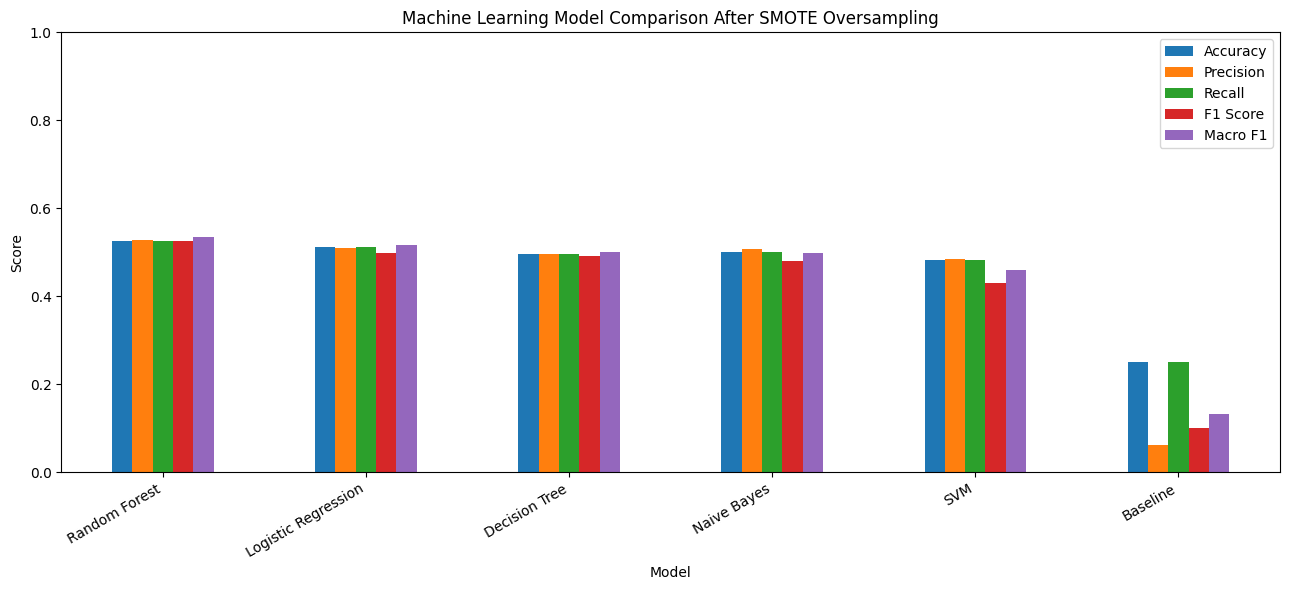

In [26]:
plot_data = results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Macro F1"
    ]
]

plot_data.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title(
    "Machine Learning Model Comparison After SMOTE Oversampling"
)
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## **26. Best Model**

In [39]:
best_model_name = results_df.iloc[0]["Model"]
best_score = results_df.iloc[0]["Macro F1"]

print("=" * 60)
print("BEST MODEL AFTER SMOTE OVERSAMPLING")
print("=" * 60)
print("Model:", best_model_name)
print("Macro F1:", round(best_score, 4))

BEST MODEL AFTER SMOTE OVERSAMPLING
Model: Random Forest
Macro F1: 0.5336


## **27. Final Classification Report**

In [28]:
best_prediction = models[
    best_model_name
]

print(
    classification_report(
        y_test,
        best_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.60      0.56      0.58      2497
         Low       0.51      0.60      0.55      3274
      Medium       0.50      0.45      0.47      4229

    accuracy                           0.53     10000
   macro avg       0.54      0.54      0.53     10000
weighted avg       0.53      0.53      0.52     10000



## **28. Confusion Matrix**

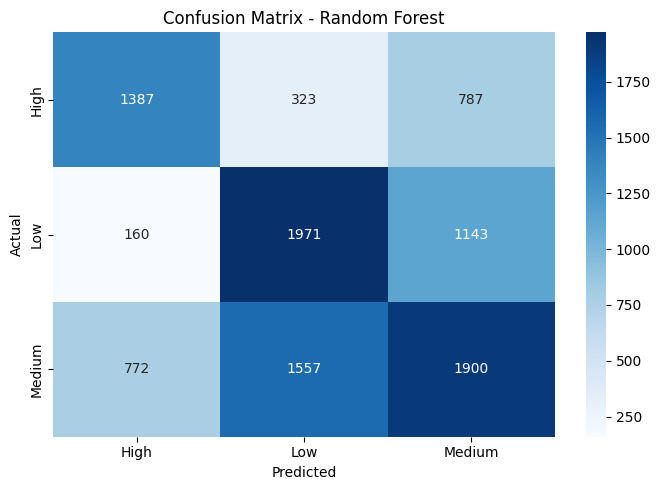

In [29]:
cm = confusion_matrix(
    y_test,
    best_prediction
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## **29. High Risk Recall**

In [30]:
report = classification_report(
    y_test,
    best_prediction,
    output_dict=True,
    zero_division=0
)

if "High" in report:

    high_recall = report["High"]["recall"]

    print(
        "High Burnout Risk Recall:",
        round(high_recall, 4)
    )

else:

    print("High class was not found.")

High Burnout Risk Recall: 0.5555


## **30. Comparing Precision, Recall and F1**

In [31]:
report = classification_report(
    y_test,
    best_prediction,
    output_dict=True,
    zero_division=0
)

class_results = []

for class_name in y.unique():

    if class_name in report:

        class_results.append({
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1 Score": report[class_name]["f1-score"],
            "Support": report[class_name]["support"]
        })

class_results_df = pd.DataFrame(class_results)

display(
    class_results_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Class,Precision,Recall,F1 Score,Support
0,High,0.5981,0.5555,0.5760,2497.000000
1,Low,0.5118,0.6020,0.5533,3274.000000
2,Medium,0.4961,0.4493,0.4715,4229.000000


## **31. Find and Select Best Models**

In [40]:
model_dictionary = {

    "Logistic Regression":
        logistic_model,

    "Naive Bayes":
        naive_bayes_model,

    "Decision Tree":
        decision_tree_model,

    "Random Forest":
        random_forest_model,

    "SVM":
        svm_model
}



best_model_name = results_df.loc[
    results_df["Macro F1"].idxmax(),
    "Model"
]



best_model = model_dictionary[
    best_model_name
]


print("Best Model Name:")
print(best_model_name)

print("\nBest Model:")
print(best_model)

Best Model Name:
Random Forest

Best Model:
RandomForestClassifier(max_depth=15, n_estimators=200, n_jobs=-1,
                       random_state=42)


## **32. Select Example Student**

In [41]:
example_students = X_test.iloc[:5].copy()


print("Example Students:")

display(example_students)

Example Students:


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
18437,Business,Graduate,3.638,12.14,Summarizing_Reading,Intermediate,1,True,11.77,4,Actively_Encouraged,5,3.823,83.39
5385,Business,Senior,3.473,6.51,Copywriting/Drafting,Advanced,4,False,14.79,2,Allowed_With_Citation,3,3.937,87.97
41097,Humanities,Sophomore,2.684,1.09,Copywriting/Drafting,Beginner,3,False,15.98,4,Allowed_With_Citation,2,2.743,63.77
46083,Business,Graduate,3.341,0.30,Ideation,Advanced,4,False,6.83,3,Strict_Ban,3,3.706,79.73
46666,STEM,Sophomore,3.402,28.99,Debugging/Troubleshooting,Advanced,3,False,1.00,7,Allowed_With_Citation,9,3.793,85.28


## **33. Predict Burnout Risk Level**

In [42]:
example_students_processed = preprocessor.transform(
    example_students
)


predictions = best_model.predict(
    example_students_processed
)




prediction_results = example_students.copy()




prediction_results[
    "Predicted Burnout Risk"
] = predictions


print("Prediction Results:")

display(prediction_results)

Prediction Results:


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Predicted Burnout Risk
18437,Business,Graduate,3.638,12.14,Summarizing_Reading,Intermediate,1,True,11.77,4,Actively_Encouraged,5,3.823,83.39,High
5385,Business,Senior,3.473,6.51,Copywriting/Drafting,Advanced,4,False,14.79,2,Allowed_With_Citation,3,3.937,87.97,Low
41097,Humanities,Sophomore,2.684,1.09,Copywriting/Drafting,Beginner,3,False,15.98,4,Allowed_With_Citation,2,2.743,63.77,Low
46083,Business,Graduate,3.341,0.30,Ideation,Advanced,4,False,6.83,3,Strict_Ban,3,3.706,79.73,Medium
46666,STEM,Sophomore,3.402,28.99,Debugging/Troubleshooting,Advanced,3,False,1.00,7,Allowed_With_Citation,9,3.793,85.28,High


## **34 Actual vs Predicted Result**

In [43]:
actual_values = y_test.iloc[:5].values




comparison_results = pd.DataFrame({

    "Student Number":

        range(
            1,
            len(predictions) + 1
        ),

    "Actual Burnout Risk":

        actual_values,

    "Predicted Burnout Risk":

        predictions

})



comparison_results[
    "Correct Prediction"
] = (

    comparison_results[
        "Actual Burnout Risk"
    ]

    ==

    comparison_results[
        "Predicted Burnout Risk"
    ]
)


print("Actual vs Predicted Results:")

display(comparison_results)

Actual vs Predicted Results:


,Student Number,Actual Burnout Risk,Predicted Burnout Risk,Correct Prediction
0,1,Medium,High,False
1,2,Medium,Low,False
2,3,Low,Low,True
3,4,Medium,Medium,True
4,5,High,High,True


# **35. Prediction Probabilities**

In [46]:
if hasattr(best_model, "predict_proba"):




    probabilities = best_model.predict_proba(
        example_students_processed
    )




    probability_results = pd.DataFrame(

        probabilities,

        columns=best_model.classes_

    )



    probability_results.insert(

        0,

        "Student Number",

        range(
            1,
            len(example_students) + 1
        )

    )



    probability_results[
        "Predicted Burnout Risk"
    ] = predictions


    print("Prediction Probabilities:")



    probability_columns = list(
        best_model.classes_
    )



    display(
        probability_results.style.format(
            {

                column: "{:.4f}"

                for column in probability_columns

            }
        )
    )


else:

    print(
        "The best model does not support "
        "prediction probabilities."
    )

Prediction Probabilities:


,Student Number,High,Low,Medium,Predicted Burnout Risk
0,1,0.5410,0.1630,0.2960,High
1,2,0.1534,0.4244,0.4222,Low
2,3,0.1121,0.4604,0.4275,Low
3,4,0.2675,0.3216,0.4109,Medium
4,5,0.8144,0.0412,0.1444,High
